<a href="https://colab.research.google.com/github/ani85-coder/Feb-Internship-NLP-Preprocessing-Engine/blob/main/Fine_Tuning_BERT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Install libraries
!pip install -q transformers accelerate scikit-learn pandas numpy matplotlib seaborn tqdm

In [2]:
# Import libraries
import re
import random
import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSequenceClassification
from torch.optim import AdamW
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.auto import tqdm

In [3]:
#Set seed and device
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [6]:
# Load dataset
df = pd.read_csv("/content/IMDB Dataset.csv")
print("Shape:", df.shape)
df.head()

Shape: (50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [7]:
# Check columns and missing values
print("Columns:", df.columns.tolist())
print("\nMissing values:")
print(df.isnull().sum())

Columns: ['review', 'sentiment']

Missing values:
review       0
sentiment    0
dtype: int64


In [8]:
# Handle missing values
df = df.dropna(subset=["review", "sentiment"]).copy()
df["review"] = df["review"].astype(str)
print("Shape after dropping missing values:", df.shape)

Shape after dropping missing values: (50000, 2)


In [9]:
# Clean text
def clean_text(text):
    text = text.lower()
    text = re.sub(r"<.*?>", " ", text)
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_review"] = df["review"].apply(clean_text)
df = df[df["clean_review"].str.len() > 0].copy()

df[["review", "clean_review"]].head()

,review,clean_review
0,One of the other reviewers has mentioned that ...,one of the other reviewers has mentioned that ...
1,A wonderful little production. <br /><br />The...,a wonderful little production the filming tech...
2,I thought this was a wonderful way to spend ti...,i thought this was a wonderful way to spend ti...
3,Basically there's a family where a little boy ...,basically there s a family where a little boy ...
4,"Petter Mattei's ""Love in the Time of Money"" is...",petter mattei s love in the time of money is a...


In [10]:
# Encode labels
label_map = {"negative": 0, "positive": 1}

if df["sentiment"].dtype == "object":
    df["label"] = df["sentiment"].str.lower().map(label_map)
else:
    df["label"] = df["sentiment"].astype(int)

df = df.dropna(subset=["label"]).copy()
df["label"] = df["label"].astype(int)

print(df["label"].value_counts())
df[["clean_review", "sentiment", "label"]].head()

label
1    25000
0    25000
Name: count, dtype: int64


,clean_review,sentiment,label
0,one of the other reviewers has mentioned that ...,positive,1
1,a wonderful little production the filming tech...,positive,1
2,i thought this was a wonderful way to spend ti...,positive,1
3,basically there s a family where a little boy ...,negative,0
4,petter mattei s love in the time of money is a...,positive,1


In [11]:
#Split dataset into train, validation, test
train_texts, temp_texts, train_labels, temp_labels = train_test_split(
    df["clean_review"].tolist(),
    df["label"].tolist(),
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

val_texts, test_texts, val_labels, test_labels = train_test_split(
    temp_texts,
    temp_labels,
    test_size=0.5,
    random_state=42,
    stratify=temp_labels
)

print("Train size:", len(train_texts))
print("Validation size:", len(val_texts))
print("Test size:", len(test_texts))

Train size: 40000
Validation size: 5000
Test size: 5000


In [12]:

#Load BERT tokenizer
MODEL_NAME = "bert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
MAX_LEN = 128

print("Tokenizer loaded successfully")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Tokenizer loaded successfully


In [13]:
#Create custom dataset class
class SentimentDataset(Dataset):
    def __init__(self, texts, labels, tokenizer, max_len=128):
        self.texts = texts
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            truncation=True,
            padding="max_length",
            max_length=self.max_len,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": torch.tensor(label, dtype=torch.long)
        }

In [14]:
# Create datasets and dataloaders

train_dataset = SentimentDataset(train_texts, train_labels, tokenizer, MAX_LEN)
val_dataset = SentimentDataset(val_texts, val_labels, tokenizer, MAX_LEN)
test_dataset = SentimentDataset(test_texts, test_labels, tokenizer, MAX_LEN)

BATCH_SIZE = 8

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

print("Dataloaders created successfully")

Dataloaders created successfully


In [15]:
# Build helper functions

def build_model():
    model = AutoModelForSequenceClassification.from_pretrained(
        MODEL_NAME,
        num_labels=2
    )
    return model

def freeze_all_bert_layers(model):
    for param in model.bert.parameters():
        param.requires_grad = False

def unfreeze_last_n_bert_layers(model, n=2):
    for param in model.bert.parameters():
        param.requires_grad = False

    for layer in model.bert.encoder.layer[-n:]:
        for param in layer.parameters():
            param.requires_grad = True

    for param in model.classifier.parameters():
        param.requires_grad = True

def print_trainable_parameters(model):
    total = 0
    trainable = 0
    for p in model.parameters():
        total += p.numel()
        if p.requires_grad:
            trainable += p.numel()
    print(f"Trainable params: {trainable:,} / {total:,} ({100 * trainable / total:.2f}%)")

In [16]:
# Evaluation function
def evaluate_model(model, data_loader):
    model.eval()
    all_preds = []
    all_labels = []
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(data_loader, leave=False):
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            logits = outputs.logits

            total_loss += loss.item()

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    avg_loss = total_loss / len(data_loader)
    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)
    cm = confusion_matrix(all_labels, all_preds)

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "confusion_matrix": cm,
        "y_true": all_labels,
        "y_pred": all_preds
    }

In [17]:
# Training function

def train_model(model, train_loader, val_loader, epochs=2, lr=2e-5):
    model.to(device)

    optimizer = AdamW(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=lr
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_accuracy": [],
        "val_precision": [],
        "val_recall": [],
        "val_f1": []
    }

    for epoch in range(epochs):
        model.train()
        total_train_loss = 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}")
        for batch in loop:
            optimizer.zero_grad()

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["labels"].to(device)

            outputs = model(
                input_ids=input_ids,
                attention_mask=attention_mask,
                labels=labels
            )

            loss = outputs.loss
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()
            loop.set_postfix(train_loss=loss.item())

        avg_train_loss = total_train_loss / len(train_loader)
        val_metrics = evaluate_model(model, val_loader)

        history["train_loss"].append(avg_train_loss)
        history["val_loss"].append(val_metrics["loss"])
        history["val_accuracy"].append(val_metrics["accuracy"])
        history["val_precision"].append(val_metrics["precision"])
        history["val_recall"].append(val_metrics["recall"])
        history["val_f1"].append(val_metrics["f1"])

        print(f"\nEpoch {epoch+1}/{epochs}")
        print(f"Train Loss: {avg_train_loss:.4f}")
        print(f"Val Loss: {val_metrics['loss']:.4f}")
        print(f"Val Accuracy: {val_metrics['accuracy']:.4f}")
        print(f"Val Precision: {val_metrics['precision']:.4f}")
        print(f"Val Recall: {val_metrics['recall']:.4f}")
        print(f"Val F1: {val_metrics['f1']:.4f}")

    return history

In [18]:
# Confusion matrix plot

def plot_confusion_matrix(cm, title):
    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=["Negative", "Positive"],
        yticklabels=["Negative", "Positive"]
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.show()

In [19]:

# Freeze BERT, train classifier only

model_exp1 = build_model()
freeze_all_bert_layers(model_exp1)

for param in model_exp1.classifier.parameters():
    param.requires_grad = True

print("Experiment 1: Freeze all BERT layers")
print_trainable_parameters(model_exp1)

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Experiment 1: Freeze all BERT layers
Trainable params: 1,538 / 109,483,778 (0.00%)


In [20]:
# Train Experiment 1

history_exp1 = train_model(
    model_exp1,
    train_loader,
    val_loader,
    epochs=1,
    lr=2e-5
)

Epoch 1/1:   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]


Epoch 1/1
Train Loss: 0.6747
Val Loss: 0.6536
Val Accuracy: 0.6416
Val Precision: 0.5958
Val Recall: 0.8808
Val F1: 0.7108


  0%|          | 0/625 [00:00<?, ?it/s]

Experiment 1 - Test Results
Accuracy : 0.6460
Precision: 0.6013
Recall   : 0.8664
F1 Score : 0.7099

Classification Report:
              precision    recall  f1-score   support

    Negative       0.76      0.43      0.55      2500
    Positive       0.60      0.87      0.71      2500

    accuracy                           0.65      5000
   macro avg       0.68      0.65      0.63      5000
weighted avg       0.68      0.65      0.63      5000



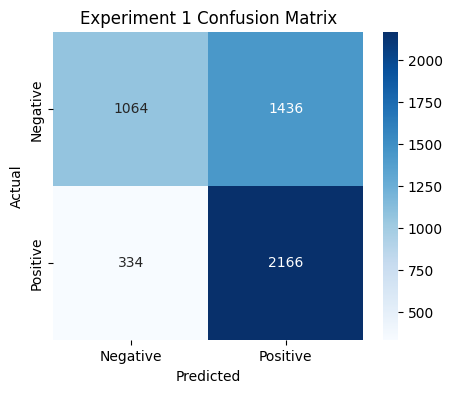

In [21]:
# Evaluate Experiment 1 on test set
test_metrics_exp1 = evaluate_model(model_exp1, test_loader)

print("Experiment 1 - Test Results")
print(f"Accuracy : {test_metrics_exp1['accuracy']:.4f}")
print(f"Precision: {test_metrics_exp1['precision']:.4f}")
print(f"Recall   : {test_metrics_exp1['recall']:.4f}")
print(f"F1 Score : {test_metrics_exp1['f1']:.4f}")

print("\nClassification Report:")
print(classification_report(
    test_metrics_exp1["y_true"],
    test_metrics_exp1["y_pred"],
    target_names=["Negative", "Positive"]
))

plot_confusion_matrix(test_metrics_exp1["confusion_matrix"], "Experiment 1 Confusion Matrix")

In [22]:
# Fine-tune last 2 BERT layers
model_exp2 = build_model()
unfreeze_last_n_bert_layers(model_exp2, n=2)

print("Experiment 2: Fine-tune last 2 BERT layers")
print_trainable_parameters(model_exp2)

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Experiment 2: Fine-tune last 2 BERT layers
Trainable params: 14,177,282 / 109,483,778 (12.95%)


In [23]:
# Train Experiment 2

history_exp2 = train_model(
    model_exp2,
    train_loader,
    val_loader,
    epochs=1,
    lr=2e-5
)

Epoch 1/1:   0%|          | 0/5000 [00:00<?, ?it/s]

  0%|          | 0/625 [00:00<?, ?it/s]


Epoch 1/1
Train Loss: 0.3402
Val Loss: 0.2848
Val Accuracy: 0.8742
Val Precision: 0.8959
Val Recall: 0.8468
Val F1: 0.8707


  0%|          | 0/625 [00:00<?, ?it/s]

Experiment 2 - Test Results
Accuracy : 0.8852
Precision: 0.9147
Recall   : 0.8496
F1 Score : 0.8810

Classification Report:
              precision    recall  f1-score   support

    Negative       0.86      0.92      0.89      2500
    Positive       0.91      0.85      0.88      2500

    accuracy                           0.89      5000
   macro avg       0.89      0.89      0.89      5000
weighted avg       0.89      0.89      0.89      5000



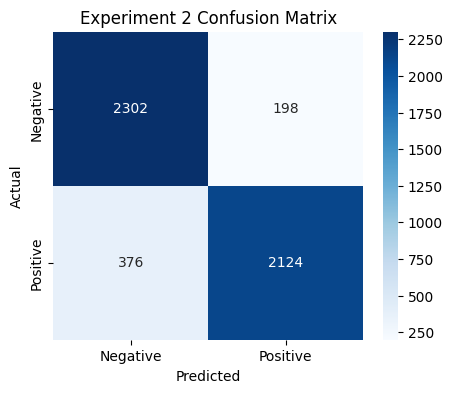

In [24]:
#Evaluate Experiment 2 on test set
test_metrics_exp2 = evaluate_model(model_exp2, test_loader)

print("Experiment 2 - Test Results")
print(f"Accuracy : {test_metrics_exp2['accuracy']:.4f}")
print(f"Precision: {test_metrics_exp2['precision']:.4f}")
print(f"Recall   : {test_metrics_exp2['recall']:.4f}")
print(f"F1 Score : {test_metrics_exp2['f1']:.4f}")

print("\nClassification Report:")
print(classification_report(
    test_metrics_exp2["y_true"],
    test_metrics_exp2["y_pred"],
    target_names=["Negative", "Positive"]
))

plot_confusion_matrix(test_metrics_exp2["confusion_matrix"], "Experiment 2 Confusion Matrix")

In [26]:
#Final conclusion print
# Create comparison table
comparison = pd.DataFrame({
    "Experiment": [
        "Freeze BERT, train classifier only",
        "Fine-tune last 2 BERT layers"
    ],
    "Accuracy": [
        test_metrics_exp1["accuracy"],
        test_metrics_exp2["accuracy"]
    ],
    "Precision": [
        test_metrics_exp1["precision"],
        test_metrics_exp2["precision"]
    ],
    "Recall": [
        test_metrics_exp1["recall"],
        test_metrics_exp2["recall"]
    ],
    "F1 Score": [
        test_metrics_exp1["f1"],
        test_metrics_exp2["f1"]
    ]
})

# Find best experiment
best_exp = comparison.iloc[comparison["F1 Score"].idxmax()]

print("Final Comparison:\n")
print(comparison)

print("\nBest Experiment Based on F1 Score:")
print(best_exp["Experiment"])

Final Comparison:

                           Experiment  Accuracy  Precision  Recall  F1 Score
0  Freeze BERT, train classifier only    0.6460   0.601333  0.8664  0.709931
1        Fine-tune last 2 BERT layers    0.8852   0.914729  0.8496  0.880962

Best Experiment Based on F1 Score:
Fine-tune last 2 BERT layers
